Imbalance Dataset : 900:0
                    100:1

UPSAMPLING AND DOWNSAMPLING

In [3]:
import numpy as np
import pandas as pd

In [4]:
np.random.seed(123)   ##set random seed for reproducibility

n_samples=1000
class_0_ratio=0.9
n_class_0=int(n_samples*class_0_ratio)
n_class_1=n_samples-n_class_0

In [5]:
n_class_0,n_class_1

(900, 100)

In [6]:
##CREATE MY DATAFRAME WITH IMBALANCE DATASET

class_0 = pd.DataFrame({
    'feature1': np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature2': np.random.normal(loc=0,scale=1,size=n_class_0),
    'target': [0]*n_class_0
})

class_1= pd.DataFrame({
    'feature1': np.random.normal(loc=2,scale=1,size=n_class_1),
    'feature2': np.random.normal(loc=2,scale=1,size=n_class_1),
    'target': [1]*n_class_1
})

# Combine dataframes
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df

,feature1,feature2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1


In [7]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

UPSAMPLING

In [8]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [9]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, ##sample with replacement
         n_samples=len(df_majority),
         random_state=42
         )

In [10]:
df_minority_upsampled.shape

(900, 3)

In [11]:
df_minority_upsampled.head()

,feature1,feature2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [12]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [13]:
df_upsampled.head()

,feature1,feature2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [14]:
df_upsampled.tail()

,feature1,feature2,target
952,1.188902,2.189189,1
965,3.919526,1.980541,1
976,2.810326,3.604614,1
942,3.621531,2.168229,1
974,1.160887,2.489203,1


In [15]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

DOWNSAMPLING

In [16]:
##CREATE MY DATAFRAME WITH IMBALANCE DATASET

class_0 = pd.DataFrame({
    'feature1': np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature2': np.random.normal(loc=0,scale=1,size=n_class_0),
    'target': [0]*n_class_0
})

class_1= pd.DataFrame({
    'feature1': np.random.normal(loc=2,scale=1,size=n_class_1),
    'feature2': np.random.normal(loc=2,scale=1,size=n_class_1),
    'target': [1]*n_class_1
})

# Combine dataframes
df = pd.concat([class_0, class_1]).reset_index(drop=True)
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [17]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [18]:
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=False,   ##not replace as we need to downsample
         n_samples=len(df_minority),
         random_state=42
         )

In [19]:
df_majority_downsampled.shape

(100, 3)

In [20]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])
df_downsampled['target'].value_counts()

target
1    100
0    100
Name: count, dtype: int64

SMOTE (SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE)\

It involves generating synthetic instances of the minority class by interpolating between existing instances.

In [21]:
from sklearn.datasets import make_classification

In [22]:
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                        weights=[0.9],random_state=12)

In [23]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [24]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

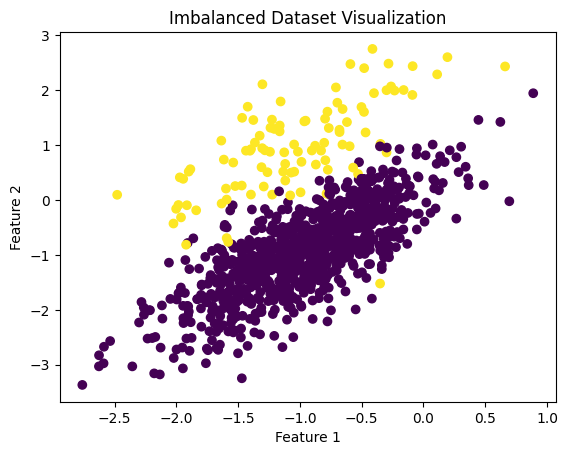

In [27]:
import matplotlib.pyplot as plt

plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Imbalanced Dataset Visualization')
plt.show()

In [33]:
# Install imbalanced-learn library

In [43]:
import imblearn
from imblearn.over_sampling import SMOTE

# Initialize SMOTE oversampler
oversample = SMOTE()

# Apply SMOTE to the dataset
X_resampled, y_resampled = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

ImportError: cannot import name 'parse_version' from 'sklearn.utils' (c:\code files\code\penv\lib\site-packages\sklearn\utils\__init__.py)

In [38]:
print(X_resampled.shape)  # (1800, 2)
print(y_resampled.shape)  # (1800,)

NameError: name 'X_resampled' is not defined

In [ ]:
import numpy as np

print(np.sum(y_resampled == 0))  # 900
print(np.sum(y_resampled == 1))  # 900

In [ ]:
oversampled_df = pd.concat([
    pd.DataFrame(X_resampled, columns=['f1', 'f2']),
    pd.DataFrame(y_resampled, columns=['target'])
], axis=1)

plt.scatter(oversampled_df['f1'], oversampled_df['f2'], c=oversampled_df['target'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset After Applying SMOTE')
plt.show()